In [1]:
import pandas as pd
df = pd.read_csv('datasets\\telco_customer_churn.csv')
df.shape

(7043, 21)

In [2]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

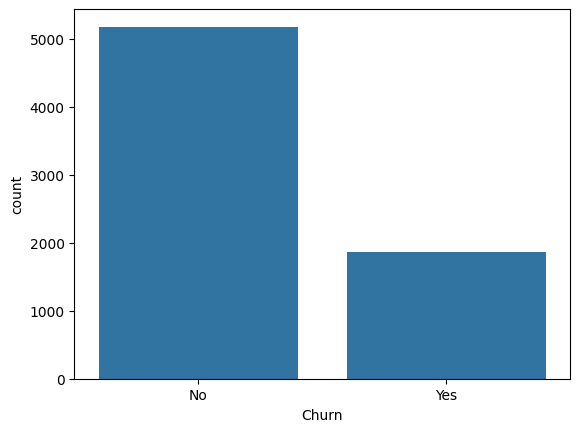

In [8]:
import seaborn as sns
sns.barplot(df['Churn'].value_counts())

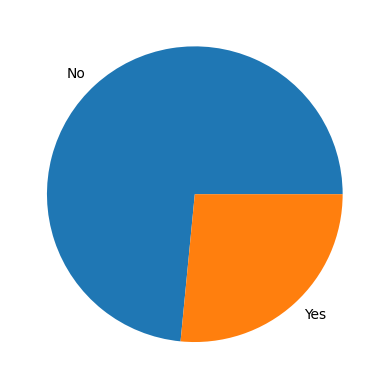

In [12]:
import matplotlib.pyplot as plt
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['No','Yes'],normalize=True)
plt.show()

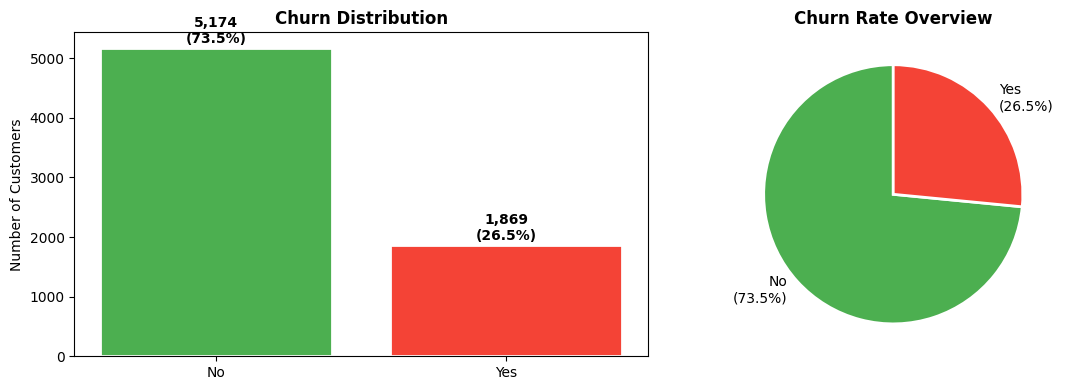

Churn rate: 26.5%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=2)
for i, (label, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 80, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts.values, labels=[f'{l}\n({v/len(df)*100:.1f}%)'
             for l, v in churn_counts.items()],
            colors=colors, autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Overview', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Churn rate: {(df["Churn"]=="Yes").mean()*100:.1f}%')


In [16]:
(df['TotalCharges'] == ' ').sum()

11

In [17]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [20]:
df.groupby('Contract')['Churn']

In [21]:
df['Churn_Int'] = (df['Churn'] == 'Yes').astype(int)
df['Churn_Int'].value_counts()

Churn_Int
0    5174
1    1869
Name: count, dtype: int64

In [22]:
df.groupby("Contract")['Churn_Int'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_Int, dtype: float64

In [23]:
# Step 1: Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Step 2: Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Step 3: Drop ID column
df = df.drop('customerID', axis=1)

# Step 4: Define feature groups
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols + ['Churn']]

print(f'Numeric features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'\nTarget distribution:')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')


Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn_Int']

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


C:\Users\rahit\AppData\Local\Temp\ipykernel_2056\975734103.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [25]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn_Int']

In [29]:
df['Partner'].nunique()

2

In [30]:
for col in cat_cols:
    print(f"No.of unique for {col} is {df[col].nunique()}\n")
    print(f"Unique values of {col}\n {df[col].unique()}")

No.of unique for gender is 2

Unique values of gender
 ['Female' 'Male']
No.of unique for Partner is 2

Unique values of Partner
 ['Yes' 'No']
No.of unique for Dependents is 2

Unique values of Dependents
 ['No' 'Yes']
No.of unique for PhoneService is 2

Unique values of PhoneService
 ['No' 'Yes']
No.of unique for MultipleLines is 3

Unique values of MultipleLines
 ['No phone service' 'No' 'Yes']
No.of unique for InternetService is 3

Unique values of InternetService
 ['DSL' 'Fiber optic' 'No']
No.of unique for OnlineSecurity is 3

Unique values of OnlineSecurity
 ['No' 'Yes' 'No internet service']
No.of unique for OnlineBackup is 3

Unique values of OnlineBackup
 ['Yes' 'No' 'No internet service']
No.of unique for DeviceProtection is 3

Unique values of DeviceProtection
 ['No' 'Yes' 'No internet service']
No.of unique for TechSupport is 3

Unique values of TechSupport
 ['No' 'Yes' 'No internet service']
No.of unique for StreamingTV is 3

Unique values of StreamingTV
 ['No' 'Yes' 'No i

In [31]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
X = df.drop('Churn', axis = 1)
y = df['Churn']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} samples | churn rate: {y_train.mean()*100:.1f}%")
print(f'Test:  {len(X_test):,} samples  | Churn rate: {y_test.mean()*100:.1f}%')
models = {
    'LogisticRegression':LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs = -1
    )
}

Train: 5,634 samples | churn rate: 26.5%
Test:  1,409 samples  | Churn rate: 26.5%


In [36]:
import time
results = []
trained_pipes = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(pipe, X_train, y_train, cv = 5, scoring='roc_auc')
    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test, y_pred),
        'Precision':precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Roc_AUC' : roc_auc_score(y_test, y_prob),
        'CV AUC (mean)': cv_auc.mean(),
        'Train time(s)': round(elapsed, 3),
    })
    trained_pipes[name] = pipe
comparision_df = pd.DataFrame(results)
print('='*80)
print("BASELINE MODEL COMPARISON")
print('='*80)
print(comparision_df.round(4).to_string(index=False))

BASELINE MODEL COMPARISON
             Model  Accuracy  Precision  Recall  F1  Roc_AUC  CV AUC (mean)  Train time(s)
LogisticRegression       1.0        1.0     1.0 1.0      1.0            1.0          0.058
     Decision Tree       1.0        1.0     1.0 1.0      1.0            1.0          0.035
     Random Forest       1.0        1.0     1.0 1.0      1.0            1.0          0.200


In [38]:
df=pd.read_csv('datasets\\telco_customer_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Step 2: Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Step 3: Drop ID column
df = df.drop('customerID', axis=1)

# Step 4: Define feature groups
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols + ['Churn']]

print(f'Numeric features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'\nTarget distribution:')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')


# Step 5: Build preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Step 6: Train/test split (stratified — keeps churn ratio same in both sets)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} samples | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test:  {len(X_test):,} samples  | Churn rate: {y_test.mean()*100:.1f}%')


models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

results = []
trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'CV AUC (mean)': cv_auc.mean(),
        'CV AUC (std)': cv_auc.std(),
        'Train Time (s)': round(elapsed, 3),
    })
    trained_pipes[name] = pipe

comparison_df = pd.DataFrame(results)
print('=' * 80)
print('BASELINE MODEL COMPARISON TABLE')
print('=' * 80)
print(comparison_df.round(4).to_string(index=False))

C:\Users\rahit\AppData\Local\Temp\ipykernel_2056\523317164.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%
Train: 5,634 samples | Churn rate: 26.5%
Test:  1,409 samples  | Churn rate: 26.5%
BASELINE MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  CV AUC (mean)  CV AUC (std)  Train Time (s)
Logistic Regression    0.7381     0.5043  0.7834 0.6136   0.8416         0.8454        0.0141           0.058
      Decision Tree    0.7544     0.5260  0.7567 0.6206   0.8318         0.8214        0.0176           0.038
      Random Forest    0.7807     0.6102  0.4813 0.5381   0.8194         0.8239        0.0118           0.278


In [39]:
rf_pipeline = Pipeline([('prep', preprocessor),
                        ('model', RandomForestClassifier(
                            class_weight='balanced', 
                            random_state=42, n_jobs=-1))])
param_grid = {
    'model__n_estimators': [50,100,200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [1,5,10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv = cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
45 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rahit\AppData\Roaming\Python\Python312\site-

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLine...
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_split': [1, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='roc_auc', verbose=1)

In [40]:
print(f'Best cv roc-auc: {grid_search.best_score_}')

Best cv roc-auc: 0.8450148500031581


In [41]:
print('best estimator', grid_search.best_estimator_)

best estimator Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
          

In [42]:
grid_search.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 10,
 'model__n_estimators': 200}

In [43]:
grid_search.best_index_

17

In [44]:
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [45]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
print(f"\nTest Set Results:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")


Test Set Results:
  Accuracy:  0.7615
  Precision: 0.5382
  Recall:    0.7166
  F1:        0.6147
  ROC-AUC:   0.8391


In [46]:
import joblib
joblib.dump(best_model, 'churn_model.pkl')

['churn_model.pkl']

In [47]:
import pandas as pd
import joblib

def run_inference(raw_df: pd.DataFrame, model_path: str = 'churn_model.pkl') -> pd.DataFrame:
    """
    Load a saved churn Pipeline and return predictions for raw_df.
    Returns a DataFrame with columns: predicted_churn, churn_probability.
    """
    # Step 1: load the saved pipeline
    loaded_model = joblib.load(model_path)
    # Step 2: make a copy so the original DataFrame is not modified
    df = raw_df.copy()
    # Step 3: drop CustomerID if present
    if 'CustomerID' in df.columns:
        df = df.drop(columns=['CustomerID'])
    # Step 4: drop Churn label column if present
    if 'Churn' in df.columns:
        df = df.drop(columns=['Churn'])
    # Step 5: fix TotalCharges dtype (coerce to numeric, fill NaN with 0)
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(
            df['TotalCharges'], errors='coerce'
        ).fillna(0)
    # Step 6: call loaded_model.predict() and loaded_model.predict_proba()
    predictions = loaded_model.predict(df)
    # Step 7: build and return the results DataFrame
    probs = loaded_model.predict_proba(df)[:, 1]
    results = pd.DataFrame(
        {
            'predicted_churn' : predictions.astype(int),
            'churn_probability' : probs.round(4)
        }
    )
    return results

if __name__ == "__main__":
    # Build the sample_input DataFrame exactly as shown above and call run_inference

    sample_input = pd.DataFrame({
        'CustomerID':      ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU'],
        'gender':          ['Female', 'Male', 'Male', 'Male', 'Female'],
        'SeniorCitizen':   [0, 0, 0, 0, 0],
        'Partner':         ['Yes', 'No', 'No', 'No', 'No'],
        'Dependents':      ['No', 'No', 'No', 'No', 'No'],
        'tenure':          [1, 34, 2, 45, 2],
        'PhoneService':    ['No', 'Yes', 'Yes', 'No', 'Yes'],
        'MultipleLines':   ['No phone service', 'No', 'No', 'No phone service', 'No'],
        'InternetService': ['DSL', 'DSL', 'DSL', 'DSL', 'Fiber optic'],
        'OnlineSecurity':  ['No', 'Yes', 'Yes', 'Yes', 'No'],
        'OnlineBackup':    ['Yes', 'No', 'Yes', 'No', 'No'],
        'DeviceProtection':['No', 'Yes', 'No', 'Yes', 'No'],
        'TechSupport':     ['No', 'No', 'No', 'Yes', 'No'],
        'StreamingTV':     ['No', 'No', 'No', 'No', 'No'],
        'StreamingMovies': ['No', 'No', 'No', 'No', 'No'],
        'Contract':        ['Month-to-month', 'One year', 'Month-to-month', 'One year', 'Month-to-month'],
        'PaperlessBilling':['Yes', 'No', 'Yes', 'No', 'Yes'],
        'PaymentMethod':   ['Electronic check', 'Mailed check', 'Mailed check',
                            'Bank transfer (automatic)', 'Electronic check'],
        'MonthlyCharges':  [29.85, 56.95, 53.85, 42.30, 70.70],
        'TotalCharges':    [' ', '1889.50', '108.15', '1840.75', ' '],
        'Churn':           ['No', 'No', 'Yes', 'No', 'Yes'],
    })

    output = run_inference(sample_input)
    print(output)

   predicted_churn  churn_probability
0                1             0.6411
1                0             0.0709
2                1             0.6568
3                0             0.0509
4                1             0.8437
